# Assignment 3: Reinforcement Learning

**Goal**: Get familiar with a reinforcement learning approach to solve multi-armed bandit problem.

**Note**: All assignments are individual, group work and/or the use of generative AI tools for completing the assignments in any capacity and/or copy paste from any resource are considered as plagiarism and reported.

We will implement a value-based reinforcement learning approach with two
algorithm variations: epsilon-greedy (e-greedy) and upper confidence bound
(UCB) algorithms and perform an analysis on their behavior.

Please answer the `Questions` and implement coding `Tasks` by filling **PLEASE FILL IN** sections. *Documentation* of your code is also important. You can find the grading scheme in implementation cells.

## 1. Introduction: Multi-Armed Bandit Problem

Imagine you are in a casino facing a row of slot machines, say there are 20 of them. Each slot machine is providing reward based on a certain probability distribution that is unknown to you.

This is your first time in this casino, thus you have no idea what to do next. You have just enough money to play for 100 times and each of these times, you can pick any machine you want and after "pulling"

What would you do?

The overall goal would of course be to find out the one that is providing the most reward, right? What should your algorithm be to get the most reward at the end?

## 2. Implementation

In [1]:
# %pip install "matplotlib>=3.7" "numpy>=1.25" "tqdm>=4.65" ipywidgets --user

In [2]:
# %pip install "matplotlib>=3.7" "numpy>=1.25" "tqdm>=4.65" --upgrade --user

In [3]:
%matplotlib inline

In [4]:
# First import the dependencies
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import trange

**Question 1 (0-0.25-0.5pt):** Please write down mathematical expressions arm selection for the e-greedy and UCB algorithms and discuss their parameters.

**Answer:**  

First, the basic formule for computing the estimated prize for $k+1$ pulling-down-the-arm attempts. It bases on the prize gained throughout all the previous and the current attempts $-$ $Q_k$ $-$ and also takes into account the difference between prize gained onto the $k$ step and gained after all the $k$ attempts: $[R_k - Q_k]$. This last component is needed simply for consideration how much the algorithm overestimates or underestimates current prize reward. If $Rk > Qk$, the action outperforms predictions, so $Q$ increases; if $Rk<Qk$, it underperforms, so $Q$ decreases. The $\alpha$ here is for regularization: how much we consider this info about the under/overestimation bias of the algorithm.
$$

Q_{k+1} = Q_k + \alpha [R_k - Q_k]
$$

$$
\alpha \in (0, 1]
$$

This is the formula for e-greedy algotithm:  

$$
a_t =
\begin{cases}
\arg\max_a Q_t(a), & \text{if } \mathrm{rand} < 1 - \varepsilon, \\
\mathrm{rand}(a), & \text{otherwise}
\end{cases}
$$

This is the algorithm for selecting next bandit machine. The meaning of the formula is as simple as follows: with some probability we want to change even the best performing bandit machine (for the sake of better exploration). So, if a random variable is less than $1 - \varepsilon$, we select another bandit. 


The UCB exploits just another selecting next bandit machine strategy. It uses additional component (namely $c \sqrt{\frac{\ln t}{N_t(a)}}$) that enables exploration on previously unexplored bandits. So, basically it adds bonus points to promising bandits which have been selected less frequently up to step $t$.

$$
A_t = \arg\max_a \Bigl[ Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \Bigr]
$$


---

**Task 1 (3 pt):** Please implement the e-greedy and UCB algorithms in the code given below.

In [5]:
#################################
# Grading
# 0 pts if the code does not work, code works but it is fundamentally incorrect
# 0.75 pts if the code works but some functions are incorrect and it is badly explained
# 1.5 pts if the code works but some functions are incorrect but it is explained well
# 2.25 pts if the code works very well aligned with the task without any mistakes, but it is badly explained
# 3 pts if the code works very well aligned with the task without any mistakes, and it is well explained
################################################################


# ============ PLEASE DO NOT CHANGE ============ #


def initialize(n_arms):
    rng = np.random.default_rng()
    R = rng.uniform(low=0.45, high=0.55, size=n_arms)
    R[rng.integers(n_arms)] = 0.9
    # return actual mean of the reward probabilities
    return R


# ================================================ #


# the epsilon-greedy algorithm (ignore kwargs)
def e_greedy(Q, epsilon, **kwargs):
    ########### PLEASE FILL IN ##############
    # here we follow the formula
    # with probability epsilon we select a random arm, with probability 1-e we select the arm with the highest Q value
    if np.random.random() < epsilon:
        selection = np.random.randint(len(Q))
    else:
        selection = np.argmax(Q)
    #########################################
    return selection


# The upper confidence bound algorithm (ignore kwargs)
def UCB(Q, selection_counter, t, **kwargs):
    C = 0.5  # Parameter (keep it constant)
    ########### PLEASE FILL IN ##############
    # again, just implementing the formula
    # first calculating the ucb, then selecting the arm with the highest ucb value
    ucb = Q + C * np.sqrt(np.log(t + 1) / (selection_counter + 1e-8))
    selection = np.argmax(ucb)
    #########################################
    return selection


def MAB(
    trials,  # total number of arm pulls
    n_arms,  # number of arms to pull
    epsilon,  # exploration parameter for the epsilon-greedy algorithm
    alpha,  # learning rate for updating Q-values
    init,  # initial starting value of the Q-values
    algorithm,  # the type of update: e_greedy or UCB
):
    # ============ PLEASE DO NOT CHANGE ============ #
    # initialization of the reward distributions unknown to the player
    R = initialize(n_arms)
    cumulative_reward_trend = np.zeros(trials)
    selection_trend = np.zeros(trials)
    reward_trend = np.zeros(trials)
    cumulative_reward = 0

    # initialize counter of selection for each arms
    selection_counter = np.zeros(n_arms)

    # initialize initial estimates of rewards
    Q = np.ones(n_arms) * init
    # ================================================ #

    for i in trange(trials, leave=False):
        # ============ PLEASE DO NOT CHANGE ============ #
        # select an arm to pull based on reward estimates and other
        kwargs = {
            "Q": Q,
            "epsilon": epsilon,
            "selection_counter": selection_counter,
            "t": i,
        }
        selection = algorithm(**kwargs)
        reward = np.random.normal(R[selection], 0.01)
        # ================================================ #

        ########### PLEASE FILL IN ##############
        # Update Q values
        Q[selection] = Q[selection] + alpha * (reward - Q[selection])
        ########################################

        # ============ PLEASE DO NOT CHANGE ============ #
        reward_trend[i] = reward
        selection_trend[i] = selection
        selection_counter[selection] += 1
        cumulative_reward += reward
        cumulative_reward_trend[i] = cumulative_reward
        # ================================================ #

    return reward_trend

**Question 2 (0-0.25-0.5pt):** Please explain the concept of exploration and exploitation in the context epsilon-greedy and UCB algorithm contexts.
How does the epsilon-greedy algorithm balance exploration and exploitation?


**Answer:**  
- The epsilon-greedy algorithm enables exploitation of the selected arm with a probability $1-\epsilon$ and randomly selects other arm with a chance of $\epsilon$. So, the balance is being achieved by adding randomization to the selectional process.  
- In the UCB algorithm, there is an additional component that gives bonus points to underexplored arms over better explored ones (as at $t$-step). Thus, the balance is being achieved in more conscious way: if we were using one arm over and over again (exploitation), probably it's time to alter it and try a different one (exploration mechanism)

---

## 3. Algorithm Analysis

In [6]:
# ============ PLEASE DO NOT REMOVE ============ #
def plot_experiments(experiment1, experiment2, labels):
    experiment1 = np.array(experiment1)
    experiment1_std = np.std(experiment1, axis=0)
    experiment1_mean = np.mean(experiment1, axis=0)

    experiment2 = np.array(experiment2)
    experiment2_std = np.std(experiment2, axis=0)
    experiment2_mean = np.mean(experiment2, axis=0)

    mean = [experiment1_mean, experiment2_mean]
    std = [experiment1_std, experiment2_std]

    plt.figure(figsize=(18, 6))
    y_values = np.arange(0, len(mean[0]))
    for i in range(len(mean)):
        plt.plot(y_values, mean[i], label=labels[i])
        plt.fill_between(y_values, mean[i] + std[i], mean[i] - std[i], alpha=0.2)

    plt.xlabel("Arm pulls (trials)")
    plt.ylabel("Average reward of 20 runs")

    plt.legend()


# ================================================ #

## 2. Comparison of e-greedy and UCB algorithms

Running the code below will launch all the experiments that we would like to plot and perform analysis on.

In [7]:
experiment1 = []  # epsilon greedy epsilon: 0.1 initial Q: 0
experiment2 = []  # epsilon greedy epsilon: 0.1 initial Q: 1
experiment3 = []  # epsilon greedy epsilon: 0.2 initial Q: 0

experiment4 = []  # UCB initial Q: 0
experiment5 = []  # UCB initial Q: 1

for _ in trange(20):
    # MAB(trials, n_arms, epsilon, alpha, init, algorithm)
    experiment1.append(MAB(5_000, 20, 0.1, 0.1, 0, e_greedy))
    experiment2.append(MAB(5_000, 20, 0.1, 0.1, 1, e_greedy))
    experiment3.append(MAB(5_000, 20, 0.2, 0.1, 0, e_greedy))

    experiment4.append(MAB(5_000, 20, 0.1, 0.1, 0, UCB))
    experiment5.append(MAB(5_000, 20, 0.1, 0.1, 1, UCB))

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

...

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

---
**Question 3 (0-0.5-1pt):** Plot and compare the average rewards for e-greedy and UCB algorithms for initial Q: 0 in different period of the process.

Please discuss in each phase of the process, which algorithm worked better and why?

**Answer:**  

I adjusted the plot's figure size.  

Overall, UCB algorithm performed better: it figured out the optimal machine faster (within 100 first iterations, i guess) and, although had some explorative releases near 400th step, it successfully returned to the better strategy. The e-greedy algorithm worked worse and never found the optimal arm: one might notice that the plot of the best reward gained as a result of the e-greedy algorithm is steplike: so, we can see these moments (for instance, on step number 800 or 2000) when the epsilon randomization introduced new arms, better ones. But this process seems to be fully occasional, while the UCB exploits the heuristic that led to the better results. And this is the reason why the UCB outperforms the e-greedy algorithm.

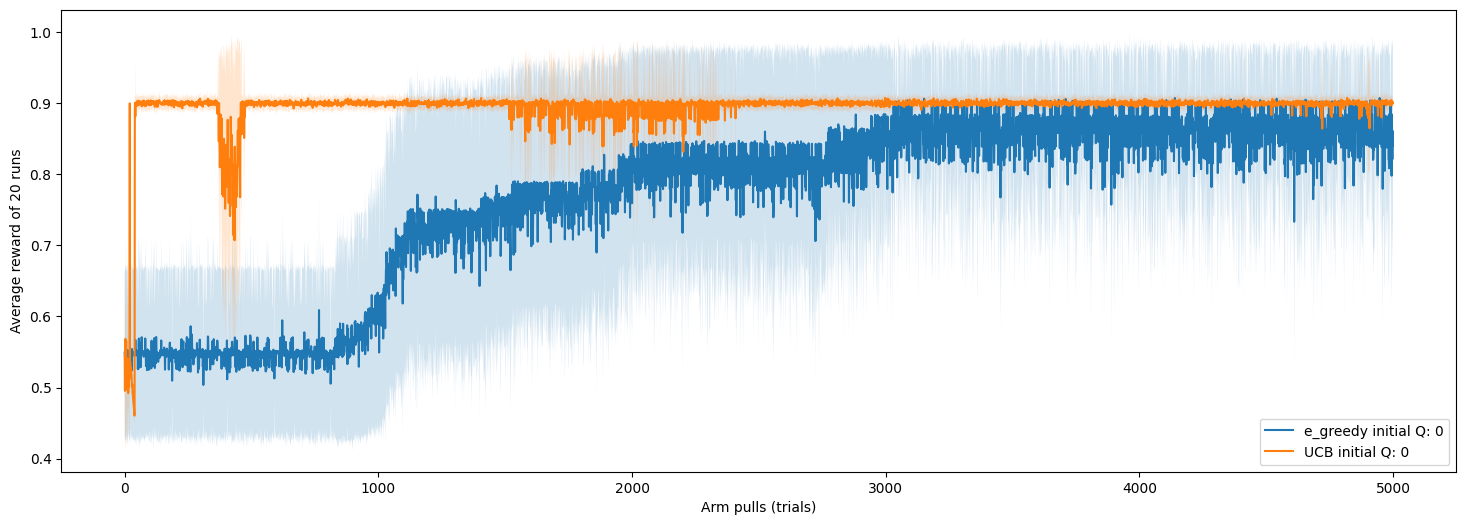

In [ ]:
label = ["e_greedy initial Q: 0", "UCB initial Q: 0"]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment1,
    experiment4,
    ########################################
    label,
)

---
**Question 4 (0-0.5-1pt):** Plot and compare the average rewards for e-greedy and UCB algorithms for initial Q: 1 in different period of the process.

Please discuss in each phase of the process, which algorithm worked better and why?

**Answer:**  
Overall, the UCB algotirhm performed better than the e-greedy algorithm. This is due to that the e-greedy algorithm still spends resources on exploration on the latter steps, while the mechanism of the UCB enables different approach. First, the options are being massively explored and then the steps of iteration are being spent on the exploiting of the best algorithm. So, that's why in the beginning the UCB grows steady from low to nearly optimal reward, while the e-greedy implementation accidentally found the right option almost at the very start. 

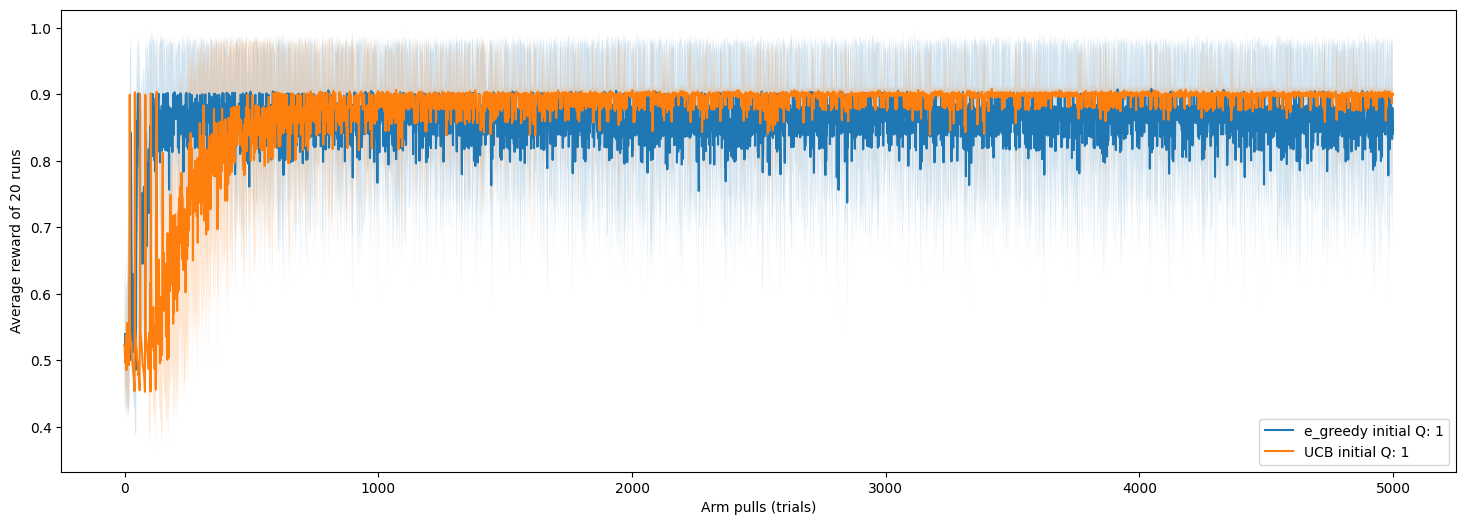

In [ ]:
label = ["e_greedy initial Q: 1", "UCB initial Q: 1"]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment2,
    experiment5,
    ########################################
    label,
)

---
**Question 5 (0-0.5-1pt):** Plot and compare the average rewards for e-greedy for initial Q: 0 for epsilon values 0.1 and 0.2 in different period of the process.

Please discuss in each phase of the process, which algorithm worked better and why?

**Answer:**  
Nothig else to be said but we can observe the difference between higher ($\epsilon = 0.2$) and lower (($\epsilon = 0.1$)) exploration potential of the same algorithm. With the epsilon equals to 0.2, the better options were being found gradually, but faster, while with the epsilon equals to 0.1, the algorithm was figuring out the better solution longer. However, this exploration privelege of the e=.2 implementation has led to the less exploitation from the middle of arm pulls and resulted in the worse overall performance. On the contrary, the e=.1 implementation has led to finding and getting more stuck with the right solution (arm), so, it obviously gained a larger reward.

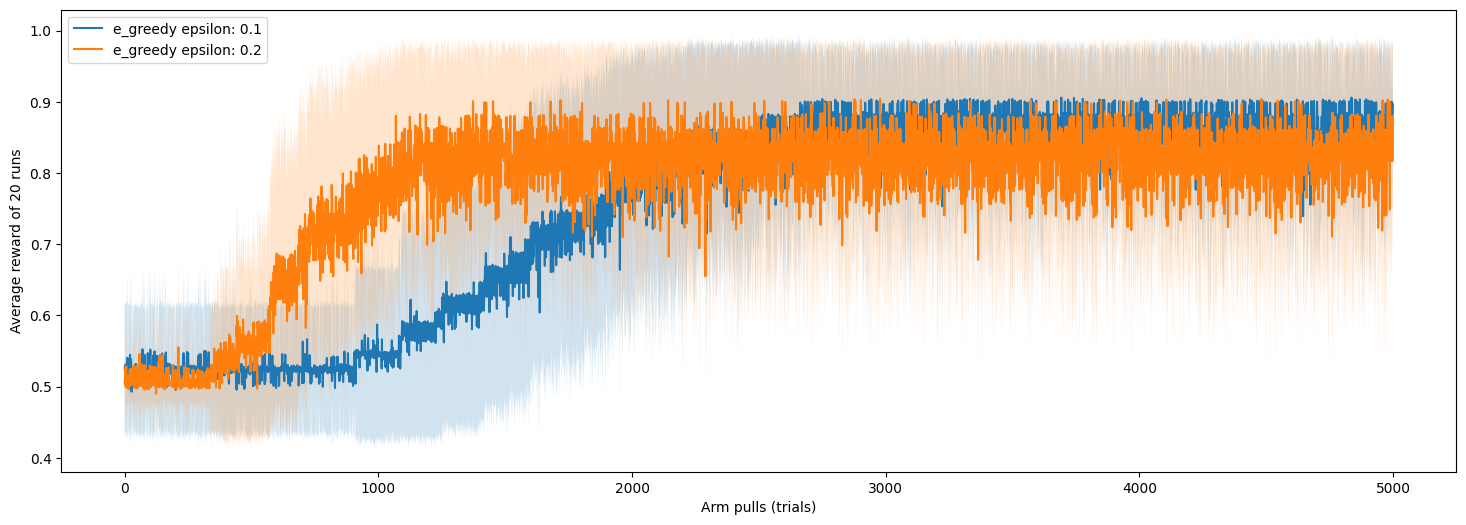

In [ ]:
label = ["e_greedy epsilon: 0.1", "e_greedy epsilon: 0.2"]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment1,
    experiment3,
    ########################################
    label,
)

---
**Question 6 (0-0.5-1pt):** Plot and compare the average rewards for e-greedy for epsilon = 0.1 initial Q: 0 and 1 in different period of the process.

Please discuss in each phase of the process, which algorithm worked better and why?

**Answer:**  
The initialization creates a bias on the basis of which the later calculations ground. The initialization with zeros provides a pessimistic bias, therefore, if we are lucky, we find the better options in the very beginning and quickly converge to the optimum (otherwise, if we are unlucky, the process of finding the right optimum drags on $-$ this scenario is shown in the plot below). The initialization with ones provides an optimistic bias, so the algorithm is less dependent on the lucky selecting at the start. Moreover, it forces broad exploration because untouched arms stay competitive even when $Q$ equals $1$. That's why the best arm gets discovered quickly in the beginning of the iterative process. So, overall, the e-greedy algorithm initializaed with an array of ones outperformed the one that was initialized with an array of zeros: it simply converged to the optimum faster.

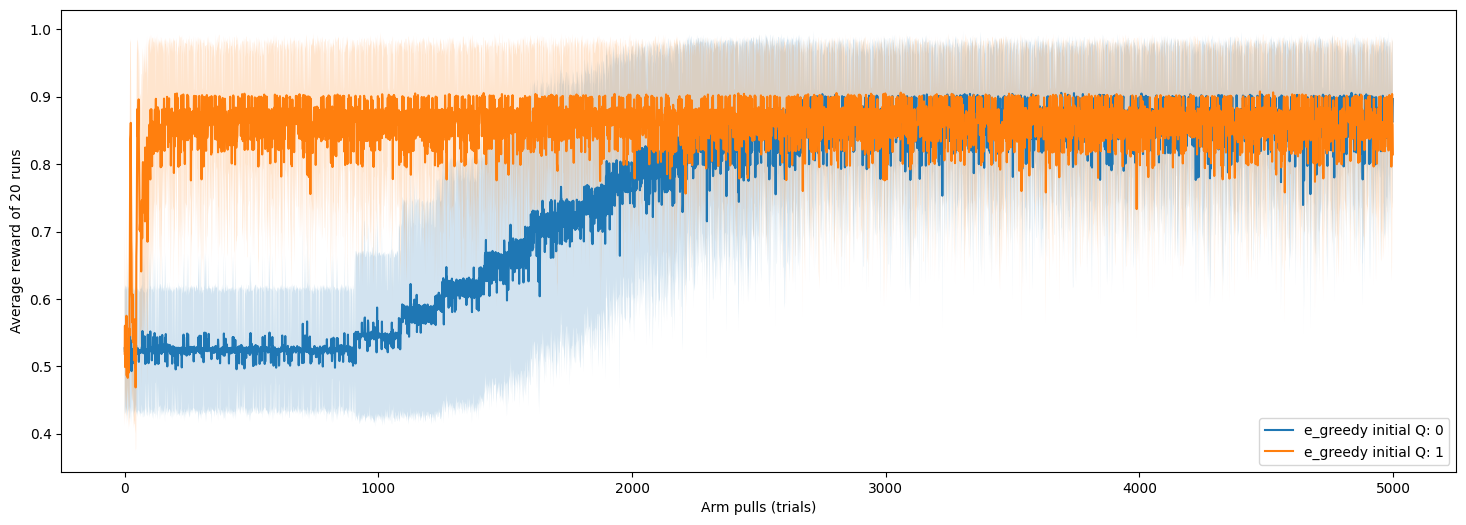

In [ ]:
label = ["e_greedy initial Q: 0", "e_greedy initial Q: 1"]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment1,
    experiment2,
    ########################################
    label,
)

---
**Question 7 (0-0.5-1pt):** Plot and compare the average rewards for UCB initial Q: 0 and 1 in different period of the process.

Please discuss in each phase of the process, which algorithm worked better and why?

**Answer:**  

Both initializations converged to the best solution quickly, but the initialization with ones seems to be having longer and broader initial exploration. Actually, the initialization of the $Q$-s  within the UCB shouldn't be that important due to the dominanating impact of the second component $c \sqrt{\frac{\ln t}{N_t(a)}}$. So, we might assume that the difference in the behaviour of the two runs of the algorithms is more or less due to the chance, randomness in running and not that substantial. You might observe the "UCB initial Q: 0" under the question 8 where it might be clearly observed that initialization with an array of zeros does also have some explorative outbursts.

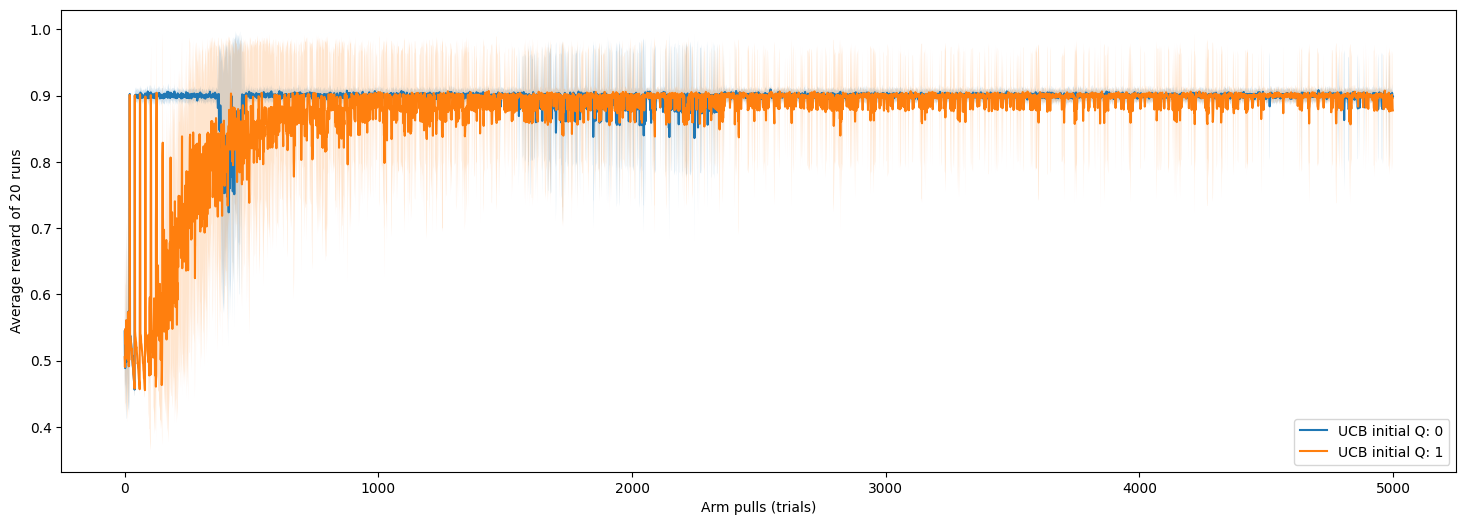

In [ ]:
label = ["UCB initial Q: 0", "UCB initial Q: 1"]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment4,
    experiment5,
    ########################################
    label,
)

---

## 3. Final remarks

**Question 8 (0-0.5-1pt):** Based on the all plots and analysis, please plot the best and worst performing algorithms and discuss the comparison? Discuss why that may be the case.

**Answer:**  

We guess that the best performing algorithm is the UCB with zero-initialization, while the worst is the e-greeady with epsilon: 0.2 initial Q: 0. The latter converge to the optimum relatively fast but actually never reaches the optimum due to the high exploration rate. The UCB performs overall better than all e-greedy algorithms because of the heuristics used in the formula for estimating next Q that outperforms the randomization of the e-greedy algorithm strategy. As mentioned in the answer to the question 7, I do not really believe that initialization values have a significant impact on the performance of the UCB algorithm, so we just selected the UCB implementation that seems to perform slightly better. 

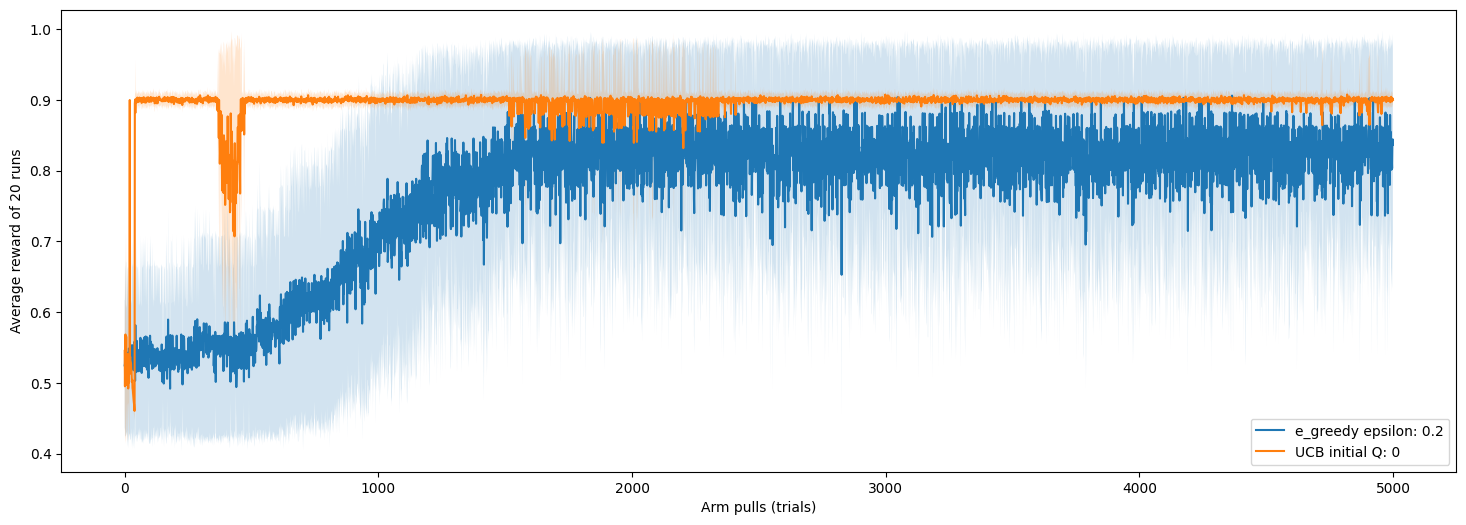

In [ ]:
# PLOT THE BEST AND WORST PERFORMING ALGORITHMS AND COMPARE
label = [
    ########### PLEASE FILL IN ##############
    "e_greedy epsilon: 0.2 initial Q: 0",
    "UCB initial Q: 0",
    ########################################
]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment3,
    experiment4,
    ########################################
    label,
)